# 10. MCH geneplot

Part of the **[Fig. 3 chapter](fig3.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [1]:
from glob import glob

import anndata
import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import seaborn as sns

from ALLCools.clustering import *
from ALLCools.integration.seurat_class import SeuratIntegration
from ALLCools.plot import *
from ALLCools.mcds import MCDS

from sklearn.metrics import pairwise_distances, roc_auc_score, average_precision_score
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression

mpl.style.use("default")
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = "Helvetica"

import warnings
warnings.filterwarnings("ignore")


/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing 

In [2]:
def dump_embedding(adata, name, n_dim=2):
    # put manifold coordinates into adata.obs
    for i in range(n_dim):
        adata.obs[f'{name}_{i}'] = adata.obsm[f'X_{name}'][:, i]
    return adata


In [3]:
indir = f'{ENTEX_ROOT}/'
outdir = f'{ENTEX_ROOT}/analysis/mCH_clustering/'


In [4]:
group_name = 'c16'


In [5]:
adata = anndata.read_h5ad(f'{outdir}L1/{group_name}/100kCH_embed.h5ad')


In [6]:
coord_base = 'tsne'
dump_embedding(adata, coord_base)


AnnData object with n_obs × n_vars = 1880 × 0
    obs: 'FinalmCReads', 'mCHFrac', 'mCGFrac', 'CisLongContact', 'Cis/Trans', 'Donor', 'Tissue', 'celltype', 'ClusterTissue', 'tsne_0', 'tsne_1', 'leiden_cons', 'leiden_cv', 'leiden_init', 'batch', 'L1_annot', 'L1', 'L2', 'L2_any', 'L2_both', 'L2_mc', 'L2_3c', 'tissue_annot', 'group', 'cluster', 'Short/Long', 'mcg_L2', 'hic_L2', 'L2_final'
    obsm: '100kCH_pc10_tsne', '100kCH_pc50_tsne', '100kCH_pca', 'X_tsne', 'pca_all'

In [7]:
meta = anndata.read_h5ad(f'{indir}clustering/merged/5kCG100k3C_summary.h5ad').obs
cluster_meta = pd.read_csv(f'{indir}clustering/merged/L2final_celltype_L2both_new.tsv', sep='\t', index_col=None, header=0)
clustermap = cluster_meta[['celltype_L2_both_abbr', 'L2_final']].drop_duplicates().set_index('L2_final')['celltype_L2_both_abbr']
meta['celltype_L2_both_abbr'] = meta['L2_final'].astype(str).map(clustermap)
adata.obs['celltype'] = meta['celltype_L2_both_abbr'].astype(str)


In [91]:
meta = anndata.read_h5ad(f'{indir}clustering/merged/5kCG100k3C_summary.h5ad').obs
cluster_meta = pd.read_csv(f'{indir}clustering/merged/L2final_celltype_L2both_new.tsv', sep='\t', index_col=None, header=0)
clustermap = cluster_meta[['celltype_L2_both', 'L2_final']].drop_duplicates().set_index('L2_final')['celltype_L2_both']
meta['celltype_L2_both'] = meta['L2_final'].astype(str).map(clustermap)
meta


,FinalmCReads,mCHFrac,mCGFrac,CisLongContact,Cis/Trans,Donor,Tissue,celltype,ClusterTissue,tsne_0,...,L2_mc,L2_3c,tissue_annot,group,cluster,Short/Long,mcg_L2,hic_L2,L2_final,celltype_L2_both
cell,,,,,,,,,,,,,,,,,,,,,
B_IOBHL_Plate10-1-A17-B13,1376030,0.011876,0.727399,186626,1.318921,PT-1LGRB,B,Fibro B,Fibro1 m1,-46.314372,...,c0,c1,Breast,c17-c0-PT-1LGRB,c17-c0,0.446979,c0,c2,c17-c0,c17-b0
B_IOBHL_Plate10-1-A17-B14,2734154,0.009636,0.706403,359403,1.171003,PT-1LGRB,B,Fibro B,Fibro3,-45.926386,...,c3,c3,Breast,c17-c6-PT-1LGRB,c17-c6,-0.255793,c7,c2,c17-c6,c17-b1
B_IOBHL_Plate10-1-A17-C2,1634700,0.012266,0.702188,206047,1.302957,PT-1LGRB,B,Fibro B,Fibro2,-43.348877,...,c2,c2,Breast,c17-c1-PT-1LGRB,c17-c1,-0.584638,c10,c0,c17-c1,c17-b1
B_IOBHL_Plate10-1-A17-D13,2407431,0.010201,0.698709,299610,1.023206,PT-1LGRB,B,Fibro B,Fibro1 m1,-41.599532,...,c0,c1,Breast,c17-c0-PT-1LGRB,c17-c0,-0.656128,c0,c2,c17-c0,c17-b0
B_IOBHL_Plate10-1-A17-D14,2644447,0.008917,0.699867,301042,0.955355,PT-1LGRB,B,Fibro B,Fibro1 m2,-42.565907,...,c1,c0,Breast,c17-c3-PT-1LGRB,c17-c3,-0.216212,c14,c8,c17-c3,c17-b0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SkGcn_C1PWV_Plate8-6-O14-O12,2156069,0.010095,0.711533,217305,1.398971,PT-1LVAN,SkGcn,Mus Skl,Sk Mus1,32.111595,...,c1,c0,Skeletal Muscle,c5-c0-PT-1LVAN,c5-c0,-0.664927,c11,c2,c5-c0,c5-b1
SkGcn_C1PWV_Plate8-6-O14-O24,2452723,0.010655,0.712112,139778,1.005821,PT-1LVAN,SkGcn,Mus Skl,Sk Mus2,26.563447,...,c0,c1,Skeletal Muscle,c5-c7-PT-1LVAN,c5-c7,-0.570078,c15,c3,c5-c7,c5-b0
SkGcn_C1PWV_Plate8-6-O14-P12,3255254,0.009585,0.701310,247522,1.286691,PT-1LVAN,SkGcn,Mus Skl,Sk Mus1,31.537040,...,c4,c0,Skeletal Muscle,c5-c4-PT-1LVAN,c5-c4,-0.869752,c3,c2,c5-c4,c5-b1


In [93]:
meta[['celltype_L2_both', 'Tissue']].to_csv(f'{indir}clustering/merged/5kCG100k3C_subtype_tissue.csv.gz')


In [8]:
knn = 25
sc.pp.neighbors(adata, n_neighbors=knn, use_rep='100kCH_pca')
sc.tl.leiden(adata, resolution=10, random_state=0, flavor='igraph')


In [19]:
adata.obs['pseudo'] = adata.obs['leiden'].astype(str) + '-' + adata.obs['celltype'].astype(str)

In [21]:
obs_pseudo = adata.obs.groupby('pseudo')[['tsne_0', 'tsne_1']].mean()
obs_pseudo['celltype'] = obs_pseudo.index.str.split('-').str[1]
obs_pseudo

,tsne_0,tsne_1,celltype
pseudo,,,
0-VIP 1,22.439258,-8.011481,VIP 1
0-VIP 2,20.566709,-9.439648,VIP 2
0-VIP 3,20.739218,-9.412441,VIP 3
1-SST 1,-2.324479,-24.882340,SST 1
1-SST 3,-2.968227,-23.127256,SST 3
...,...,...,...
70-PVALB BC 1,-23.409300,3.985242,PVALB BC 1
8-LAMP5 LHX6,-2.293882,39.401479,LAMP5 LHX6
9-PVALB BC 1,31.511719,-0.618841,PVALB BC 1


In [11]:
gene_meta_path = f'{REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gene.flat.tsv.gz'
black_list_path = f'{REF_ROOT}/blacklist/hg38-blacklist.v2.bed.gz'

chrom_to_remove = ['chrL', 'chrM', 'chrX', 'chrY']


In [12]:
gene_meta = pd.read_csv(gene_meta_path, sep='\t', header=0)
ens2gene = gene_meta.set_index('gene_id')['gene_name'].to_dict()
gene2ens = gene_meta.set_index('gene_name')['gene_id'].to_dict()


In [13]:
mcds_path_list = np.sort(glob(f'{indir}mcds/*.mcds'))
print(len(mcds_path_list))

24


In [14]:
obs_dim = 'cell'
var_dim = 'gene'


In [15]:
mcds = MCDS.open(mcds_path_list, var_dim=var_dim)
mcds

<xarray.MCDS> Size: 88GB
Dimensions:     (count_type: 2, gene: 58870, mc_type: 2, cell: 93550)
Coordinates:
  * count_type  (count_type) <U3 24B 'mc' 'cov'
  * gene        (gene) <U24 6MB 'ENSG00000223972.5' ... 'ENSG00000210196.2'
  * mc_type     (mc_type) <U3 24B 'CGN' 'CHN'
  * cell        (cell) <U34 13MB 'M1C_3C_001_Plate1-1-F3-A1' ... 'Sk_IOBHT_AR...
    gene_chrom  (gene) <U5 1MB dask.array<chunksize=(14718,), meta=np.ndarray>
    gene_end    (gene) int64 471kB dask.array<chunksize=(29435,), meta=np.ndarray>
    gene_start  (gene) int64 471kB dask.array<chunksize=(29435,), meta=np.ndarray>
Data variables:
    gene_da     (cell, gene, mc_type, count_type) uint32 88GB dask.array<chunksize=(13, 14718, 1, 1), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  gene

In [16]:
mcds = mcds.sel({obs_dim: mcds.get_index('cell').intersection(adata.obs.index)})
mcds = mcds.remove_chromosome(exclude_chromosome=chrom_to_remove, var_dim=var_dim)
mcds = mcds.remove_black_list_region(black_list_path=black_list_path, f=0.5)


2987 gene features in ['chrL', 'chrM', 'chrX', 'chrY'] removed.
1581 gene features removed due to overlapping (bedtools intersect -f 0.5) with black list regions.


In [17]:
mcds


<xarray.MCDS> Size: 2GB
Dimensions:     (count_type: 2, gene: 54302, mc_type: 2, cell: 1880)
Coordinates:
  * count_type  (count_type) <U3 24B 'mc' 'cov'
  * gene        (gene) <U24 5MB 'ENSG00000237491.9' ... 'ENSG00000079974.17'
  * mc_type     (mc_type) <U3 24B 'CGN' 'CHN'
  * cell        (cell) <U34 256kB 'M1C_3C_001_Plate1-1-F3-C14' ... 'AG_STL003...
    gene_chrom  (gene) <U5 1MB dask.array<chunksize=(14380,), meta=np.ndarray>
    gene_end    (gene) int64 434kB dask.array<chunksize=(28579,), meta=np.ndarray>
    gene_start  (gene) int64 434kB dask.array<chunksize=(28579,), meta=np.ndarray>
Data variables:
    gene_da     (cell, gene, mc_type, count_type) uint32 2GB dask.array<chunksize=(2, 14380, 1, 1), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  gene

In [22]:
mcds = mcds.assign_coords(pseudo=('cell', adata.obs.loc[mcds.get_index('cell'), 'pseudo'].values))
mcds = mcds.groupby('pseudo').sum()


In [23]:
obs_dim = 'pseudo'
mc_type = 'CHN'
mcds = mcds.sel({'mc_type':mc_type})
mcds = MCDS(mcds, obs_dim=obs_dim, var_dim=var_dim)
mcds

<xarray.MCDS> Size: 117MB
Dimensions:     (count_type: 2, gene: 54302, pseudo: 126)
Coordinates:
  * count_type  (count_type) <U3 24B 'mc' 'cov'
  * gene        (gene) <U24 5MB 'ENSG00000237491.9' ... 'ENSG00000079974.17'
    mc_type     <U3 12B 'CHN'
    gene_chrom  (gene) <U5 1MB dask.array<chunksize=(14380,), meta=np.ndarray>
    gene_end    (gene) int64 434kB dask.array<chunksize=(28579,), meta=np.ndarray>
    gene_start  (gene) int64 434kB dask.array<chunksize=(28579,), meta=np.ndarray>
  * pseudo      (pseudo) object 1kB '0-VIP 1' '0-VIP 2' ... '9-VIP 1' '9-VIP 3'
Data variables:
    gene_da     (pseudo, gene, count_type) float64 109MB dask.array<chunksize=(1, 14380, 1), meta=np.ndarray>
Attributes:
    obs_dim:  pseudo
    var_dim:  gene

<Axes: ylabel='Count'>

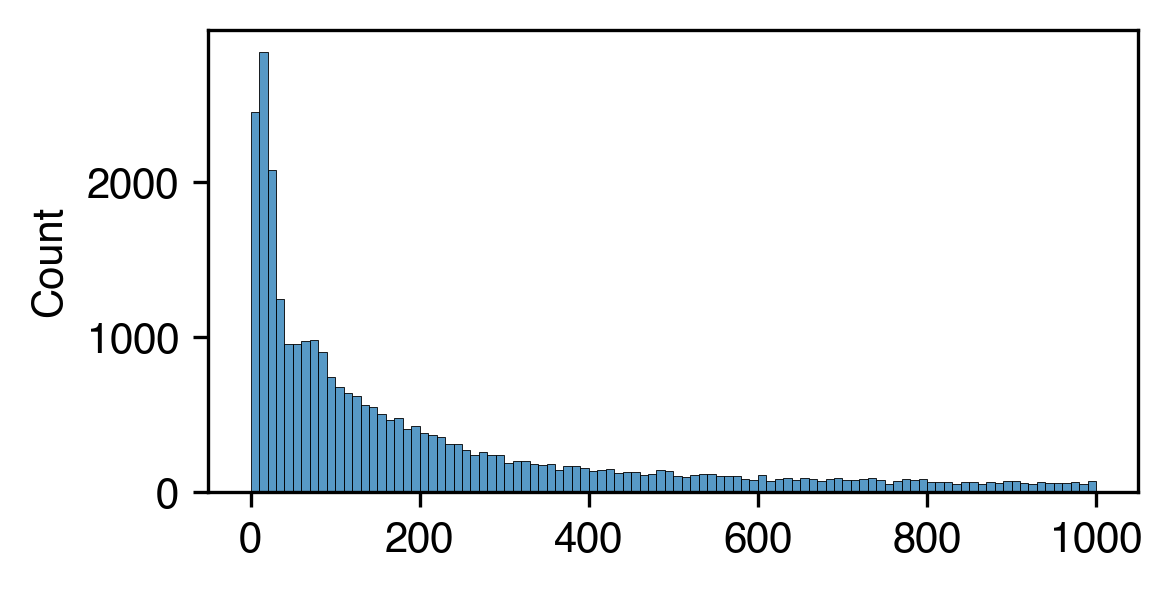

In [24]:
feature_cov_mean = mcds[f'{var_dim}_da'].sel(count_type='cov').mean(dim=obs_dim).to_pandas()
fig, ax = plt.subplots(figsize=(4,2), dpi=300)
sns.histplot(feature_cov_mean, bins=100, binrange=(0,1000), ax=ax)


In [25]:
# use_features = feature_cov_mean[feature_cov_mean > 100].index
# mcds = mcds.sel({var_dim:use_features})
mcds.add_mc_frac(var_dim=var_dim, normalize_per_cell=True, clip_norm_value=10)


In [26]:
mch_adata = mcds.get_adata(mc_type=mc_type, var_dim=var_dim, select_hvf=False)
# mch_adata = mch_adata[adata.obs.index].copy()
mch_adata = mch_adata[obs_pseudo.index].copy()
mch_adata.obs = obs_pseudo.copy()
mch_adata.var['cov_mean'] = feature_cov_mean.copy()


In [30]:
def roc_pr(ct):
    roc, pr_pos, pr_neg = [], [], []
    label = mch_adata.obs['celltype'].isin([ct]).astype(int)
    data = mch_adata.X
    for i in range(data.shape[1]):
        roc.append(roc_auc_score(label, data[:, i]))
        pr_pos.append(average_precision_score(label, data[:, i]))
        pr_neg.append(average_precision_score(label, -data[:, i]))
    return [roc, pr_pos, pr_neg]


In [17]:
# label = []
# for xx in adata.obs['celltype']:
#     if xx.split(' ')[-1].isnumeric():
#         label.append(' '.join(xx.split(' ')[:-1]))
#     else:
#         label.append(xx)
        
# adata.obs['celltype'] = label.copy()
# adata.obs['celltype'].value_counts()

celltype
SST           479
PVALB BC      467
VIP           397
LAMP5         269
SNCG          117
LAMP5 LHX6     76
PVALB ChC      75
Name: count, dtype: int64

In [31]:
label = []
for xx in mch_adata.obs['celltype']:
    if xx.split(' ')[-1].isnumeric():
        label.append(' '.join(xx.split(' ')[:-1]))
    else:
        label.append(xx)
        
mch_adata.obs['celltype'] = label.copy()
mch_adata.obs['celltype'].value_counts()


celltype
PVALB BC      38
SST           28
VIP           25
LAMP5         15
SNCG          15
LAMP5 LHX6     3
PVALB ChC      2
Name: count, dtype: int64

In [33]:
mch_adata.write_h5ad(f'{outdir}L1/{group_name}/geneCH_pseudo.h5ad')


In [34]:
from concurrent.futures import ProcessPoolExecutor, as_completed

count = mch_adata.obs['celltype'].value_counts()
leg = count.index[count>=10]

cpu = 20
with ProcessPoolExecutor(cpu) as executor:
    futures, result = {}, {}
    for ct in leg:
        future = executor.submit(roc_pr, ct)
        futures[future] = ct
    
    for future in as_completed(futures):
        ct = futures[future]
        result[ct] = future.result()
        print(f'{ct} finished')


SST finished
PVALB BC finished
VIP finished
SNCG finished
LAMP5 finished


In [35]:
for ct in leg:
    roc, pr_pos, pr_neg = result[ct]
    print(ct, mch_adata.var.index[np.argsort(pr_pos)[::-1][:5]].map(ens2gene))
    print(ct, mch_adata.var.index[np.argsort(pr_neg)[::-1][:5]].map(ens2gene))


PVALB BC Index(['LINGO2', 'NEK11', 'AC010967.1', 'AC009234.1', 'ERN1'], dtype='object', name='gene')
PVALB BC Index(['TMEM131L', 'LRRFIP1', 'SFXN5', 'NDST3', 'TSPAN9'], dtype='object', name='gene')
SST Index(['DCLK2', 'AP002961.1', 'SH3RF3', 'HECW1', 'ZNF516'], dtype='object', name='gene')
SST Index(['IQSEC1', 'TRIM67', 'AC069288.1', 'MAD1L1', 'KCNJ5'], dtype='object', name='gene')
VIP Index(['BCL11B', 'SND1', 'TSPAN5', 'OSBPL10', 'FER1L6-AS2'], dtype='object', name='gene')
VIP Index(['DSCAM', 'ASIC4', 'MAPK4', 'VIP', 'ZBTB18'], dtype='object', name='gene')
SNCG Index(['KLHL36', 'VAV2', 'AGO2', 'LINC00663', 'PHYHIP'], dtype='object', name='gene')
SNCG Index(['EPS8', 'AC093001.1', 'PLCB4', 'AL121785.1', 'AL139042.1'], dtype='object', name='gene')
LAMP5 Index(['RUNX1T1', 'RAPH1', 'XYLT1', 'TLN2', 'AC112512.1'], dtype='object', name='gene')
LAMP5 Index(['BMP6', 'SERPINE2', 'AL136164.2', 'CSMD3', 'BLOC1S5-TXNDC5'], dtype='object', name='gene')


In [36]:
marker = pd.Index(['LAMP5', 'VIP', 'PVALB', 'SST'])
marker = marker[marker.map(gene2ens).isin(mch_adata.var.index)]
marker_ch = pd.DataFrame(mch_adata[:, marker.map(gene2ens)].X, index=mch_adata.obs.index, columns=marker)


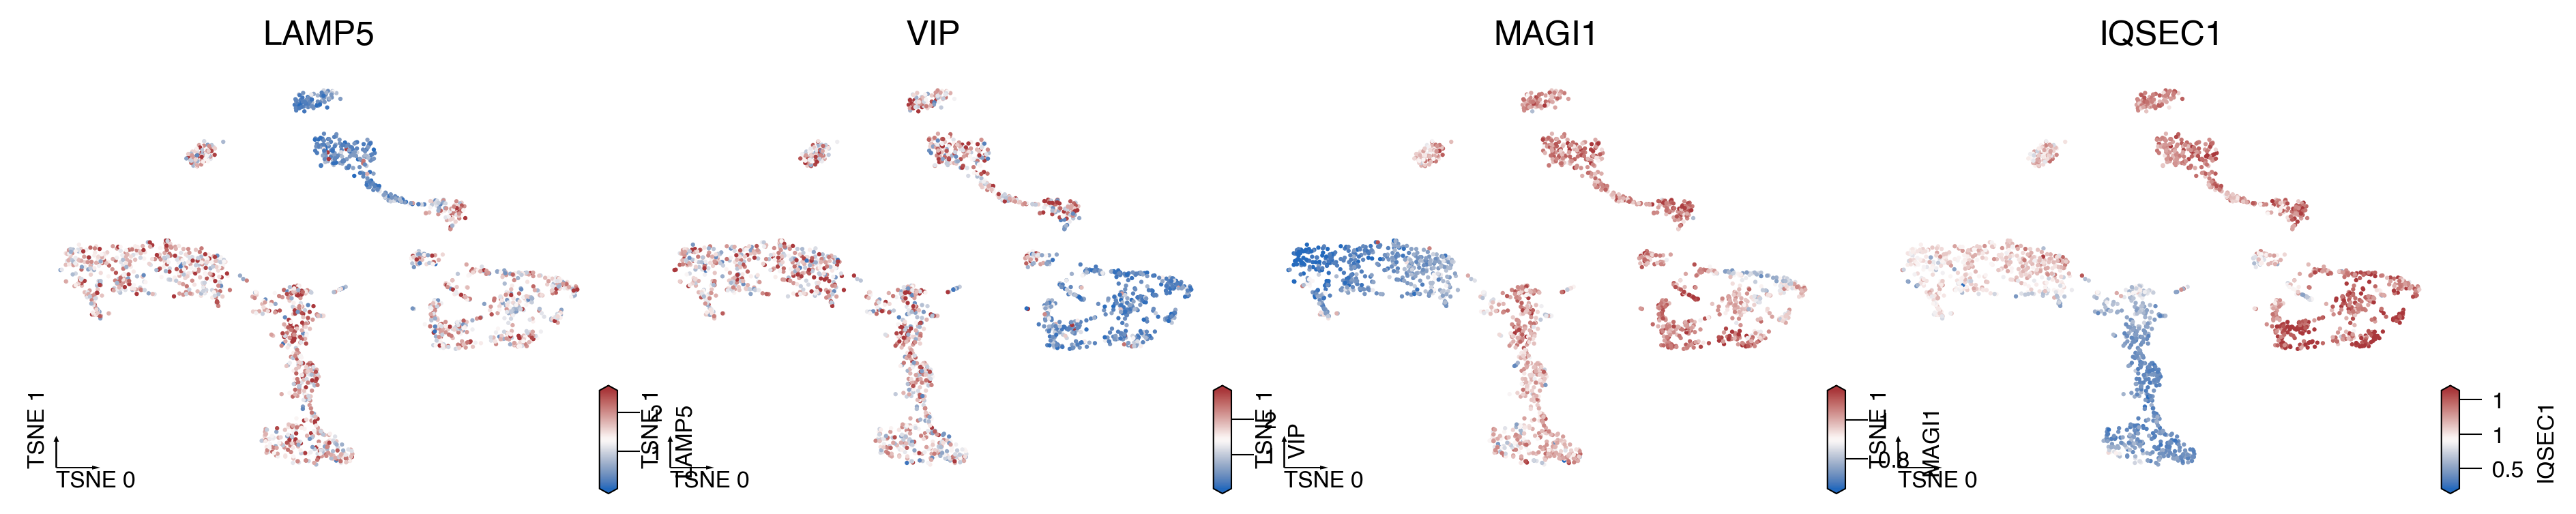

In [39]:
ncol = 4
nrow = (len(marker)-1) // ncol + 1
ds = 100/np.sqrt(adata.shape[0])
tmp = obs_pseudo.copy()

fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*3, nrow*2.4), dpi=300, constrained_layout=True)
for i, xx in enumerate(marker):
    ax = axes.flatten()[i]
    _ = continuous_scatter(ax=ax,
                           data=tmp,
                           hue=marker_ch[xx],
                           scatter_kws={'rasterized':True},
                           coord_base=coord_base,
                           max_points=None,
                           labelsize=8,
                           s=ds,
                           cmap='vlag',
                          )
    ax.set_title(xx)
    
fig.savefig(f'mCH_clustering/{group_name}_pseudo_tsne.gene.pdf', transparent=True)


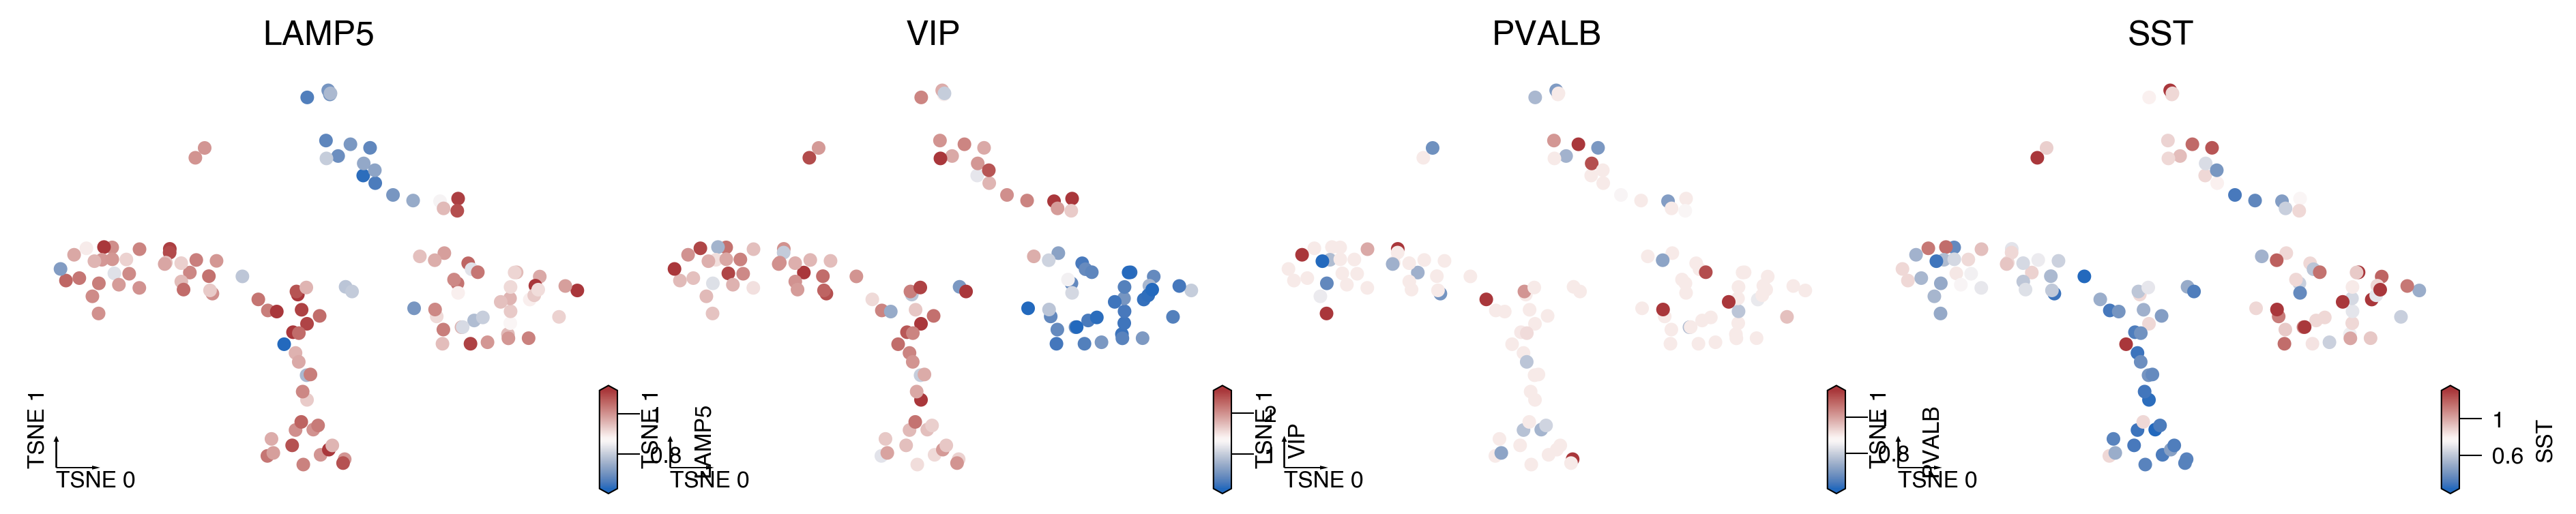

In [38]:
ncol = 4
nrow = (len(marker)-1) // ncol + 1
ds = 1000/np.sqrt(adata.shape[0])
tmp = obs_pseudo.copy()

fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*3, nrow*2.4), dpi=300, constrained_layout=True)
for i, xx in enumerate(marker):
    ax = axes.flatten()[i]
    _ = continuous_scatter(ax=ax,
                           data=tmp,
                           hue=marker_ch[xx],
                           scatter_kws={'rasterized':True},
                           coord_base=coord_base,
                           max_points=None,
                           labelsize=8,
                           s=ds,
                           cmap='vlag',
                          )
    ax.set_title(xx)
    
fig.savefig(f'mCH_clustering/{group_name}_pseudo_tsne.gene.pdf', transparent=True)


In [39]:
group_name = 'c13'


In [40]:
adata = anndata.read_h5ad(f'{outdir}L1/{group_name}/100kCH_embed.h5ad')


In [41]:
coord_base = 'tsne'
dump_embedding(adata, coord_base)


AnnData object with n_obs × n_vars = 2324 × 0
    obs: 'FinalmCReads', 'mCHFrac', 'mCGFrac', 'CisLongContact', 'Cis/Trans', 'Donor', 'Tissue', 'celltype', 'ClusterTissue', 'tsne_0', 'tsne_1', 'leiden_cons', 'leiden_cv', 'leiden_init', 'batch', 'L1_annot', 'L1', 'L2', 'L2_any', 'L2_both', 'L2_mc', 'L2_3c', 'tissue_annot', 'group', 'cluster', 'Short/Long', 'mcg_L2', 'hic_L2', 'L2_final'
    obsm: '100kCH_pc10_tsne', '100kCH_pc50_tsne', '100kCH_pca', 'X_tsne', 'pca_all'

In [42]:
meta = anndata.read_h5ad(f'{indir}clustering/merged/5kCG100k3C_summary.h5ad').obs
cluster_meta = pd.read_csv(f'{indir}clustering/merged/L2final_celltype_L2both_new.tsv', sep='\t', index_col=None, header=0)
clustermap = cluster_meta[['celltype_L2_both_abbr', 'L2_final']].drop_duplicates().set_index('L2_final')['celltype_L2_both_abbr']
meta['celltype_L2_both_abbr'] = meta['L2_final'].astype(str).map(clustermap)
adata.obs['celltype'] = meta['celltype_L2_both_abbr'].astype(str)


In [43]:
knn = 25
sc.pp.neighbors(adata, n_neighbors=knn, use_rep='100kCH_pca')
sc.tl.leiden(adata, resolution=10, random_state=0, flavor='igraph')


In [45]:
adata.obs['pseudo'] = adata.obs['leiden'].astype(str) + '-' + adata.obs['celltype'].astype(str)
obs_pseudo = adata.obs.groupby('pseudo')[['tsne_0', 'tsne_1']].mean()
obs_pseudo['celltype'] = obs_pseudo.index.str.split('-').str[1]
obs_pseudo

,tsne_0,tsne_1,celltype
pseudo,,,
0-Delta,-34.215839,-5.603509,Delta
0-Gamma,-32.564658,-4.912176,Gamma
1-Alpha,-33.650710,-3.285978,Alpha
1-Beta,-38.011129,-0.296883,Beta
1-Delta,-37.125471,-3.193342,Delta
...,...,...,...
77-Beta,5.586424,2.483761,Beta
78-Beta,10.403588,-7.377610,Beta
8-Alpha,3.950162,35.336521,Alpha


In [11]:
# gene_meta_path = f'{REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gene.flat.tsv.gz'
# black_list_path = f'{REF_ROOT}/blacklist/hg38-blacklist.v2.bed.gz'

# chrom_to_remove = ['chrL', 'chrM', 'chrX', 'chrY']


In [12]:
# gene_meta = pd.read_csv(gene_meta_path, sep='\t', header=0)
# ens2gene = gene_meta.set_index('gene_id')['gene_name'].to_dict()
# gene2ens = gene_meta.set_index('gene_name')['gene_id'].to_dict()


In [13]:
# mcds_path_list = np.sort(glob(f'{indir}mcds/*.mcds'))
# print(len(mcds_path_list))

24


In [85]:
obs_dim = 'cell'
var_dim = 'gene'


In [67]:
mcds = MCDS.open(mcds_path_list, var_dim=var_dim)
mcds

<xarray.MCDS> Size: 88GB
Dimensions:     (count_type: 2, gene: 58870, mc_type: 2, cell: 93550)
Coordinates:
  * count_type  (count_type) <U3 24B 'mc' 'cov'
  * gene        (gene) <U24 6MB 'ENSG00000223972.5' ... 'ENSG00000210196.2'
  * mc_type     (mc_type) <U3 24B 'CGN' 'CHN'
  * cell        (cell) <U34 13MB 'M1C_3C_001_Plate1-1-F3-A1' ... 'Sk_IOBHT_AR...
    gene_chrom  (gene) <U5 1MB dask.array<chunksize=(14718,), meta=np.ndarray>
    gene_end    (gene) int64 471kB dask.array<chunksize=(29435,), meta=np.ndarray>
    gene_start  (gene) int64 471kB dask.array<chunksize=(29435,), meta=np.ndarray>
Data variables:
    gene_da     (cell, gene, mc_type, count_type) uint32 88GB dask.array<chunksize=(13, 14718, 1, 1), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  gene

In [68]:
mcds = mcds.sel({obs_dim: mcds.get_index('cell').intersection(adata.obs.index)})
mcds = mcds.remove_chromosome(exclude_chromosome=chrom_to_remove, var_dim=var_dim)
mcds = mcds.remove_black_list_region(black_list_path=black_list_path, f=0.5)


2987 gene features in ['chrL', 'chrM', 'chrX', 'chrY'] removed.
1581 gene features removed due to overlapping (bedtools intersect -f 0.5) with black list regions.


In [69]:
mcds


<xarray.MCDS> Size: 2GB
Dimensions:     (count_type: 2, gene: 54302, mc_type: 2, cell: 2324)
Coordinates:
  * count_type  (count_type) <U3 24B 'mc' 'cov'
  * gene        (gene) <U24 5MB 'ENSG00000237491.9' ... 'ENSG00000079974.17'
  * mc_type     (mc_type) <U3 24B 'CGN' 'CHN'
  * cell        (cell) <U34 316kB 'ST_IOBHV_Plate7-1-M13-A13' ... 'PI_HP16134...
    gene_chrom  (gene) <U5 1MB dask.array<chunksize=(14380,), meta=np.ndarray>
    gene_end    (gene) int64 434kB dask.array<chunksize=(28579,), meta=np.ndarray>
    gene_start  (gene) int64 434kB dask.array<chunksize=(28579,), meta=np.ndarray>
Data variables:
    gene_da     (cell, gene, mc_type, count_type) uint32 2GB dask.array<chunksize=(1, 14380, 1, 1), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  gene

In [50]:
# obs_dim = 'pseudo'
# mcds = mcds.assign_coords(pseudo=('cell', adata.obs.loc[mcds.get_index('cell'), 'pseudo'].values))
# mcds = mcds.groupby(obs_dim).sum()


In [70]:
mc_type = 'CHN'
mcds = mcds.sel({'mc_type':mc_type})
mcds = MCDS(mcds, obs_dim=obs_dim, var_dim=var_dim)
mcds

<xarray.MCDS> Size: 1GB
Dimensions:     (count_type: 2, gene: 54302, cell: 2324)
Coordinates:
  * count_type  (count_type) <U3 24B 'mc' 'cov'
  * gene        (gene) <U24 5MB 'ENSG00000237491.9' ... 'ENSG00000079974.17'
    mc_type     <U3 12B 'CHN'
  * cell        (cell) <U34 316kB 'ST_IOBHV_Plate7-1-M13-A13' ... 'PI_HP16134...
    gene_chrom  (gene) <U5 1MB dask.array<chunksize=(14380,), meta=np.ndarray>
    gene_end    (gene) int64 434kB dask.array<chunksize=(28579,), meta=np.ndarray>
    gene_start  (gene) int64 434kB dask.array<chunksize=(28579,), meta=np.ndarray>
Data variables:
    gene_da     (cell, gene, count_type) uint32 1GB dask.array<chunksize=(1, 14380, 1), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  gene

<Axes: ylabel='Count'>

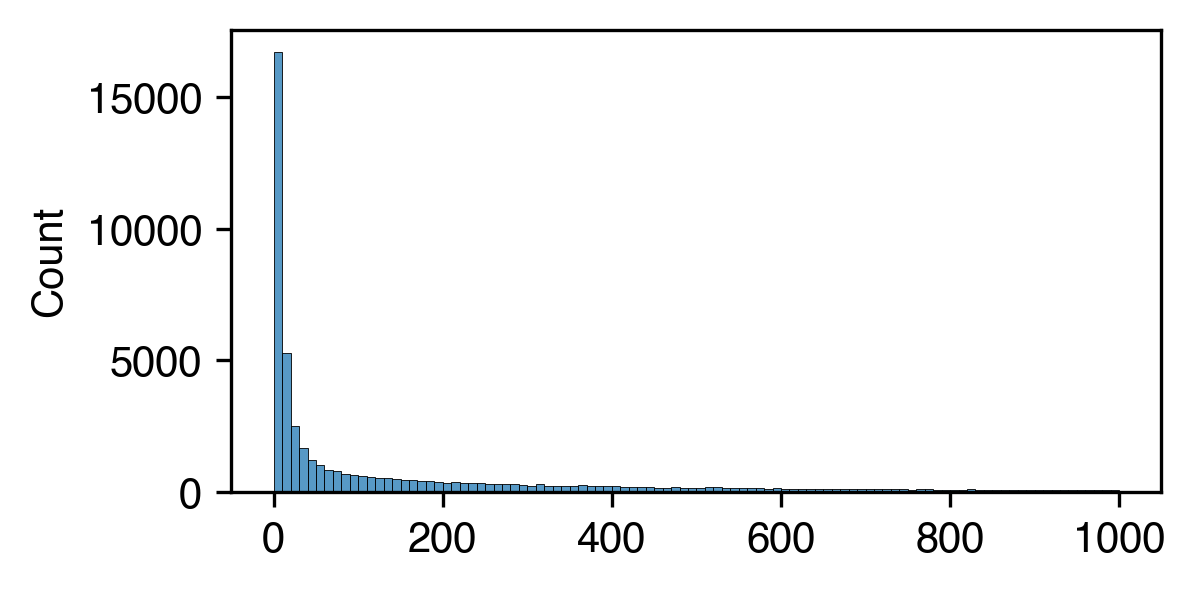

In [71]:
feature_cov_mean = mcds[f'{var_dim}_da'].sel(count_type='cov').mean(dim=obs_dim).to_pandas()
fig, ax = plt.subplots(figsize=(4,2), dpi=300)
sns.histplot(feature_cov_mean, bins=100, binrange=(0,1000), ax=ax)


In [72]:
# use_features = feature_cov_mean[feature_cov_mean > 100].index
# mcds = mcds.sel({var_dim:use_features})
mcds.add_mc_frac(var_dim=var_dim, normalize_per_cell=True, clip_norm_value=10)


In [73]:
mch_adata = mcds.get_adata(mc_type=mc_type, var_dim=var_dim, select_hvf=False)
mch_adata = mch_adata[adata.obs.index].copy()
mch_adata.obs = adata.obs.copy()
# mch_adata = mch_adata[obs_pseudo.index].copy()
# mch_adata.obs = obs_pseudo.copy()
mch_adata.var['cov_mean'] = feature_cov_mean.copy()


In [55]:
# def roc_pr(ct):
#     roc, pr_pos, pr_neg = [], [], []
#     label = mch_adata.obs['celltype'].isin([ct]).astype(int)
#     data = mch_adata.X
#     for i in range(data.shape[1]):
#         roc.append(roc_auc_score(label, data[:, i]))
#         pr_pos.append(average_precision_score(label, data[:, i]))
#         pr_neg.append(average_precision_score(label, -data[:, i]))
#     return [roc, pr_pos, pr_neg]


In [17]:
# label = []
# for xx in adata.obs['celltype']:
#     if xx.split(' ')[-1].isnumeric():
#         label.append(' '.join(xx.split(' ')[:-1]))
#     else:
#         label.append(xx)
        
# adata.obs['celltype'] = label.copy()
# adata.obs['celltype'].value_counts()

celltype
SST           479
PVALB BC      467
VIP           397
LAMP5         269
SNCG          117
LAMP5 LHX6     76
PVALB ChC      75
Name: count, dtype: int64

In [56]:
label = []
for xx in mch_adata.obs['celltype']:
    if xx.split(' ')[-1].isnumeric():
        label.append(' '.join(xx.split(' ')[:-1]))
    else:
        label.append(xx)
        
mch_adata.obs['celltype'] = label.copy()
mch_adata.obs['celltype'].value_counts()


celltype
Beta     58
Alpha    26
Gamma    11
Delta    10
Name: count, dtype: int64

In [57]:
mch_adata.write_h5ad(f'{outdir}L1/{group_name}/geneCH_pseudo.h5ad')


In [82]:
mch_adata = anndata.read_h5ad(f'{outdir}L1/{group_name}/geneCH_pseudo.h5ad')


In [58]:
from concurrent.futures import ProcessPoolExecutor, as_completed

count = mch_adata.obs['celltype'].value_counts()
leg = count.index[count>=10]

cpu = 20
with ProcessPoolExecutor(cpu) as executor:
    futures, result = {}, {}
    for ct in leg:
        future = executor.submit(roc_pr, ct)
        futures[future] = ct
    
    for future in as_completed(futures):
        ct = futures[future]
        result[ct] = future.result()
        print(f'{ct} finished')


Delta finished
Beta finished
Gamma finished
Alpha finished


In [59]:
for ct in leg:
    roc, pr_pos, pr_neg = result[ct]
    print(ct, mch_adata.var.index[np.argsort(pr_pos)[::-1][:5]].map(ens2gene))
    print(ct, mch_adata.var.index[np.argsort(pr_neg)[::-1][:5]].map(ens2gene))


Beta Index(['NCOA7', 'AC010601.1', 'RPH3A', 'NCOA7-AS1', 'ZMAT4'], dtype='object', name='gene')
Beta Index(['PFAS', 'SLC6A6', 'GLIS3', 'RDH10', 'SLC24A3'], dtype='object', name='gene')
Alpha Index(['BPHL', 'ACVR1B', 'AL031963.1', 'SYT13', 'MGAT4A'], dtype='object', name='gene')
Alpha Index(['KCNC4', 'AC111188.1', 'LRRFIP1', 'PCAT1', 'ANK1'], dtype='object', name='gene')
Gamma Index(['WASF1', 'AFDN', 'LINC01584', 'ERICH1', 'AL137186.2'], dtype='object', name='gene')
Gamma Index(['AL357140.4', 'AL157829.1', 'ITPRID1', 'HS3ST1', 'NECTIN3-AS1'], dtype='object', name='gene')
Delta Index(['ELOVL5', 'IMMP1L', 'C12orf75', 'GALNT3', 'PDE3A'], dtype='object', name='gene')
Delta Index(['SATB2', 'SGTB', 'AC106894.1', 'ABCC9', 'KIR3DX1'], dtype='object', name='gene')


In [83]:
marker = pd.Index(['INS', 'GCG', 'SST', 'PPY', 'MAFA', 'PDX1', 'ZC3H3', 'PDE3A'])
marker = marker[marker.map(gene2ens).isin(mch_adata.var.index)]
marker_ch = pd.DataFrame(mch_adata[:, marker.map(gene2ens)].X, index=mch_adata.obs.index, columns=marker)


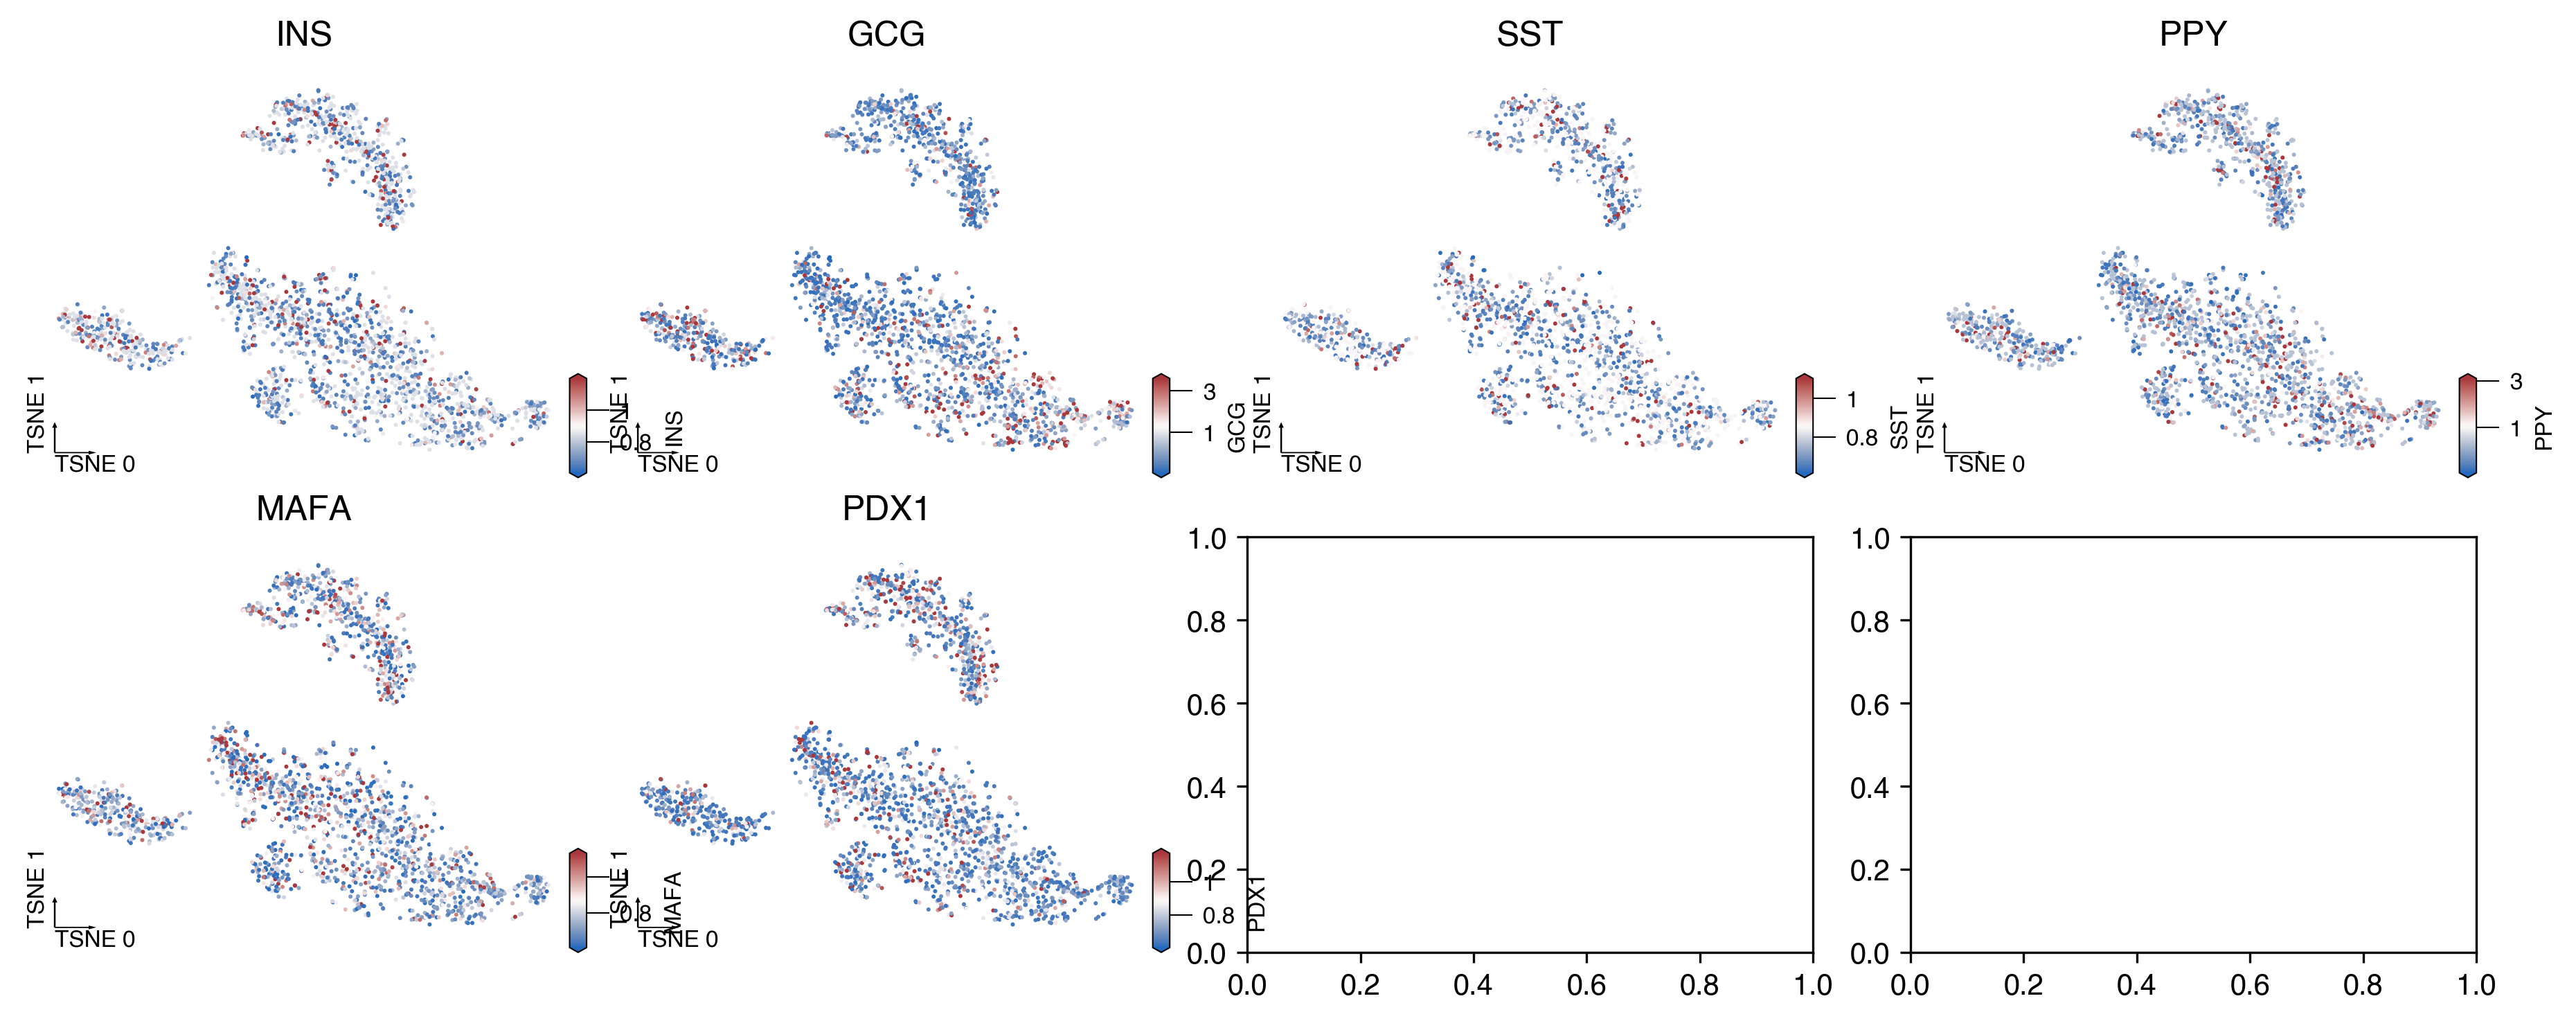

In [81]:
ncol = 4
nrow = (len(marker)-1) // ncol + 1
ds = 100/np.sqrt(adata.shape[0])
tmp = adata.obs.copy()

fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*3, nrow*2.4), dpi=300, constrained_layout=True)
for i, xx in enumerate(marker):
    ax = axes.flatten()[i]
    _ = continuous_scatter(ax=ax,
                           data=tmp,
                           hue=marker_ch[xx],
                           scatter_kws={'rasterized':True},
                           coord_base=coord_base,
                           max_points=None,
                           labelsize=8,
                           s=ds,
                           cmap='vlag',
                          )
    ax.set_title(xx)
    
fig.savefig(f'mCH_clustering/{group_name}_tsne.gene.pdf', transparent=True)


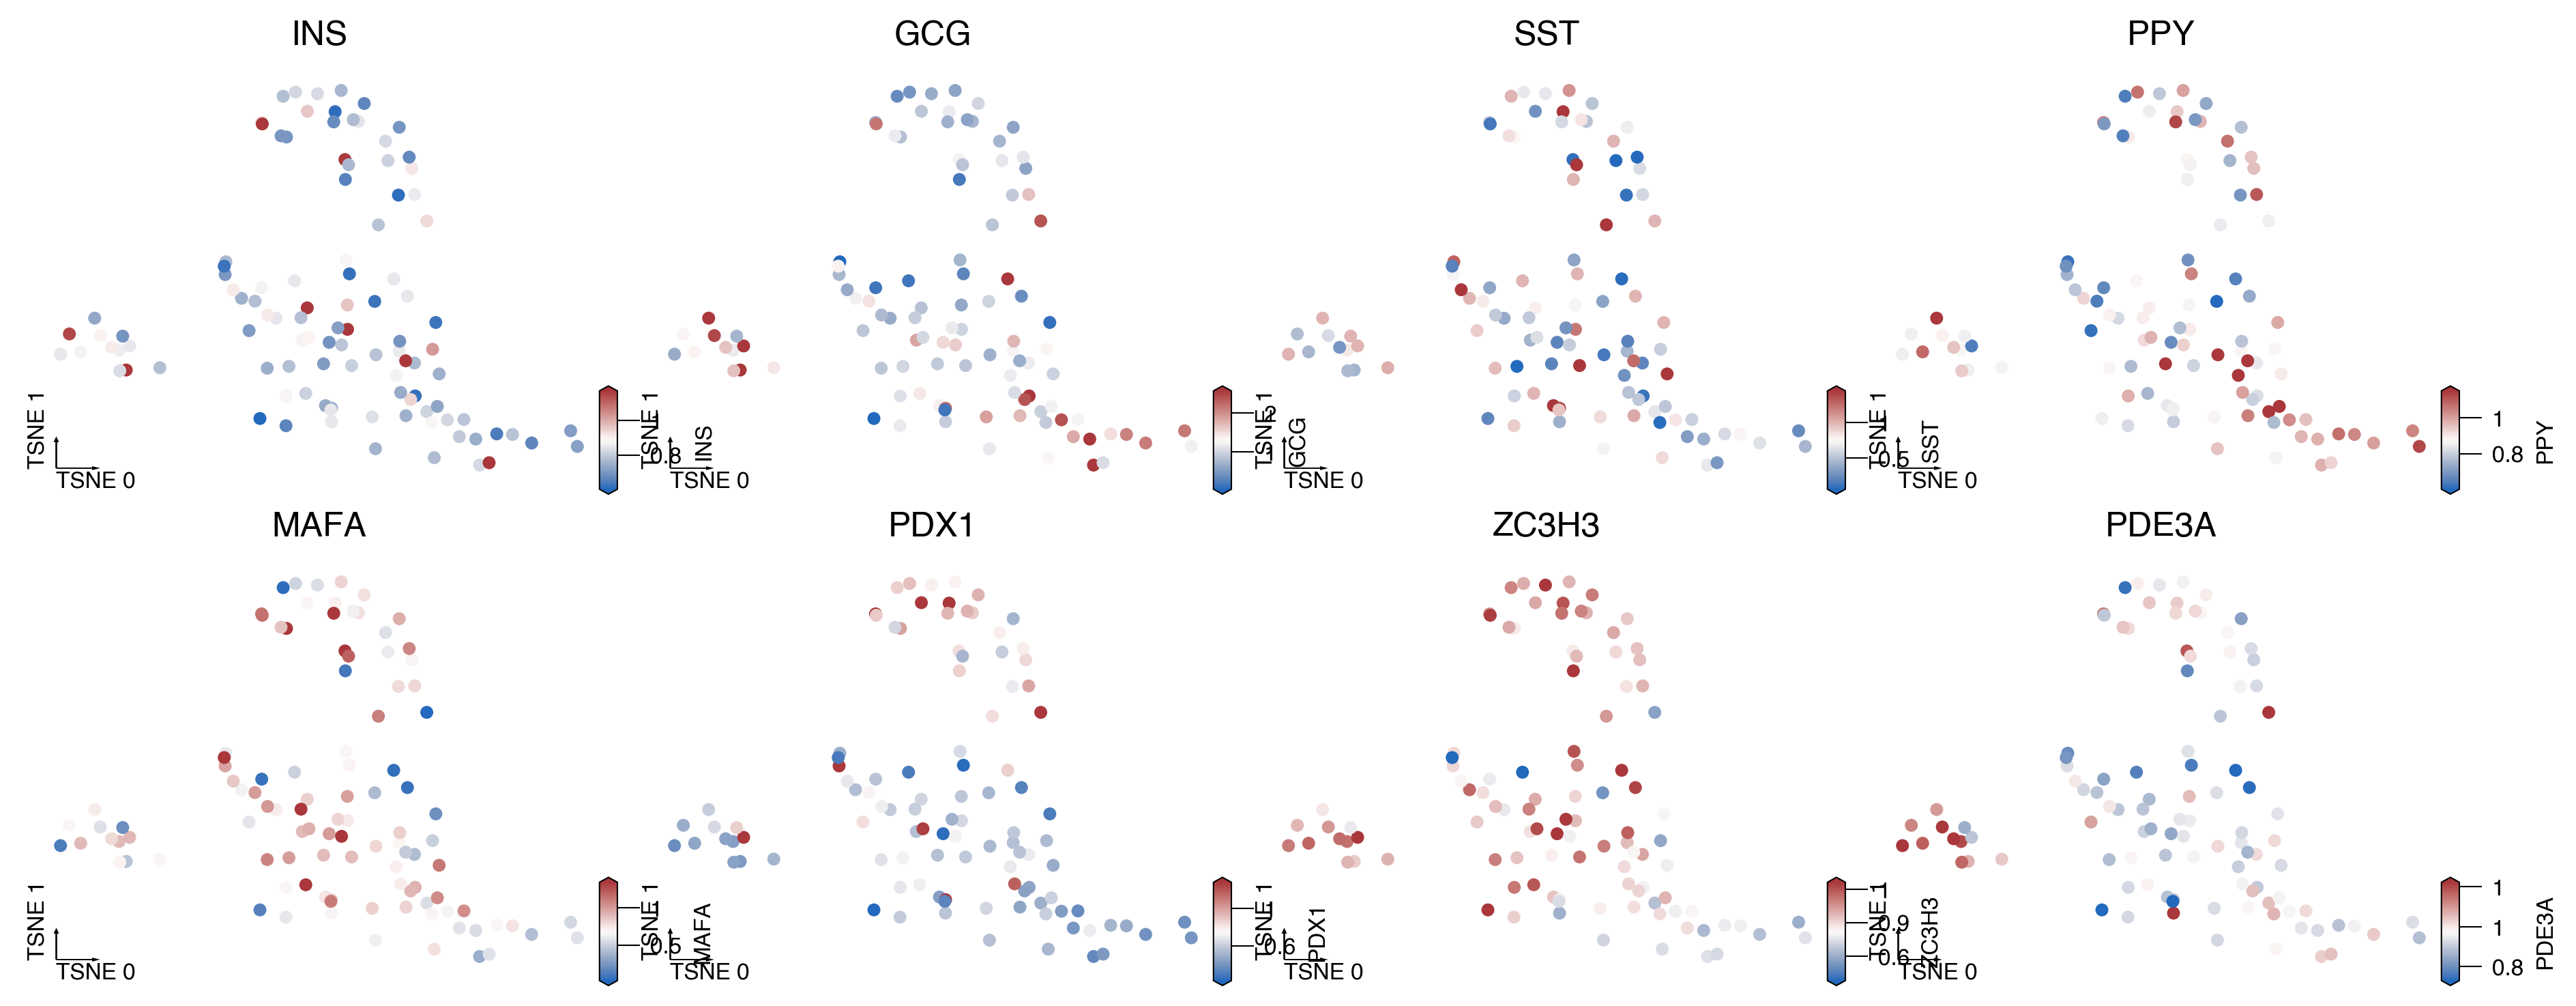

In [84]:
ncol = 4
nrow = (len(marker)-1) // ncol + 1
ds = 1000/np.sqrt(adata.shape[0])
tmp = obs_pseudo.copy()

fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*3, nrow*2.4), dpi=300, constrained_layout=True)
for i, xx in enumerate(marker):
    ax = axes.flatten()[i]
    _ = continuous_scatter(ax=ax,
                           data=tmp,
                           hue=marker_ch[xx],
                           scatter_kws={'rasterized':True},
                           coord_base=coord_base,
                           max_points=None,
                           labelsize=8,
                           s=ds,
                           cmap='vlag',
                          )
    ax.set_title(xx)
    
fig.savefig(f'mCH_clustering/{group_name}_pseudo_tsne.gene.pdf', transparent=True)
